# Uncertainty-Aware House Value Prediction with Conformal Intervals

## Goal

This notebook predicts median house values while also estimating how uncertain each prediction is.

Ordinary regression produces one point prediction:

`Predicted value = $300,000`

However, a point estimate does not indicate whether the model is highly confident or whether many values would be plausible.

This notebook instead constructs prediction intervals such as:

`Predicted interval = $235,000 to $378,000`

## Dataset

The California Housing dataset describes geographic block groups rather than individual houses.

Predictors include:

- median income
- median house age
- average rooms
- average bedrooms
- population
- average occupancy
- latitude
- longitude

The target is the median house value for the block group.

## Main question

Can conformal calibration produce reliable prediction intervals while preserving the adaptive uncertainty learned by quantile regression?

In [1]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import (
    fetch_california_housing
)

from sklearn.ensemble import (
    HistGradientBoostingRegressor
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    mean_pinball_loss
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

TEST_SIZE = 0.20
CALIBRATION_SIZE = 0.20

TARGET_COVERAGE = 0.80
MISCOVERAGE_RATE = 1 - TARGET_COVERAGE

LOWER_QUANTILE = (
    MISCOVERAGE_RATE / 2
)

MEDIAN_QUANTILE = 0.50

UPPER_QUANTILE = (
    1 - MISCOVERAGE_RATE / 2
)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)

Target coverage: 0.8
Lower quantile: 0.09999999999999998
Upper quantile: 0.9


In [2]:
housing_data = fetch_california_housing(
    as_frame=True
)

feature_df = housing_data.data.copy()

target_series = (
    housing_data.target.copy()
    * 100_000
)

target_series.name = (
    "median_house_value_usd"
)

housing_df = pd.concat(
    [
        feature_df,
        target_series
    ],
    axis=1
)

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value_usd
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [3]:
column_mapping = {
    "MedInc": "median_income",
    "HouseAge": "median_house_age",
    "AveRooms": "average_rooms",
    "AveBedrms": "average_bedrooms",
    "Population": "population",
    "AveOccup": "average_occupancy",
    "Latitude": "latitude",
    "Longitude": "longitude"
}

housing_df = housing_df.rename(
    columns=column_mapping
)

feature_columns = list(
    column_mapping.values()
)

target_column = (
    "median_house_value_usd"
)

print("Dataset shape:", housing_df.shape)
print("Features:", feature_columns)

Dataset shape: (20640, 9)
Features: ['median_income', 'median_house_age', 'average_rooms', 'average_bedrooms', 'population', 'average_occupancy', 'latitude', 'longitude']


## Data loading 

The dataset contained 20,640 California geographic block groups rather than individual houses.

Each observation included eight predictors:

- median income
- median house age
- average rooms
- average bedrooms
- population
- average occupancy
- latitude
- longitude

The original target was measured in units of $100,000 and was converted into US dollars.

The resulting target represented the recorded median house value within each geographic block group.

In [4]:
dataset_summary_df = pd.DataFrame({
    "metric": [
        "Observations",
        "Predictors",
        "Missing values",
        "Minimum target",
        "Median target",
        "Mean target",
        "Maximum target"
    ],
    "value": [
        len(housing_df),
        len(feature_columns),
        housing_df.isna().sum().sum(),
        housing_df[target_column].min(),
        housing_df[target_column].median(),
        housing_df[target_column].mean(),
        housing_df[target_column].max()
    ]
})

dataset_summary_df

,metric,value
0,Observations,20640.000000
1,Predictors,8.000000
2,Missing values,0.000000
3,Minimum target,14999.000000
4,Median target,179700.000000
5,Mean target,206855.816909
6,Maximum target,500001.000000


In [5]:
housing_df[
    feature_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
average_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
average_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
average_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


In [6]:
maximum_target = housing_df[
    target_column
].max()

number_at_cap = int(
    np.isclose(
        housing_df[target_column],
        maximum_target
    ).sum()
)

percentage_at_cap = (
    number_at_cap
    / len(housing_df)
    * 100
)

print(
    "Maximum recorded value:",
    f"${maximum_target:,.0f}"
)

print(
    "Observations at maximum:",
    number_at_cap
)

print(
    "Percentage at maximum:",
    round(percentage_at_cap, 2)
)

Maximum recorded value: $500,001
Observations at maximum: 992
Percentage at maximum: 4.81


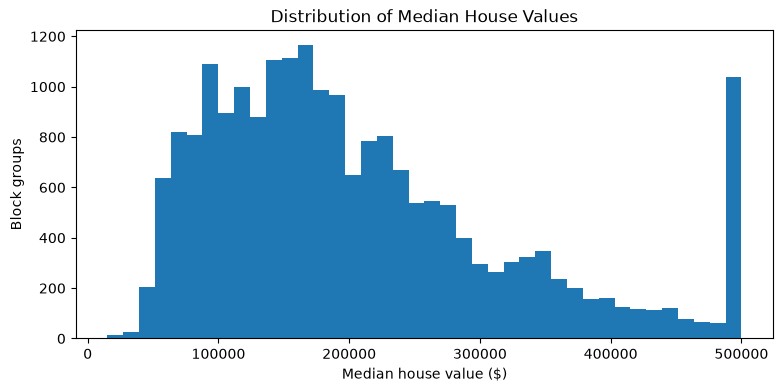

In [7]:
plt.figure(figsize=(9, 4))

plt.hist(
    housing_df[target_column],
    bins=40
)

plt.title(
    "Distribution of Median House Values"
)

plt.xlabel("Median house value ($)")
plt.ylabel("Block groups")
plt.show()

## Dataset inspection 

The dataset contained:

- 20,640 observations
- 8 predictors
- 0 missing values
- Minimum recorded value: $14,999
- Median recorded value: $179,700
- Mean recorded value: $206,855.82
- Maximum recorded value: $500,001

There were 992 observations at the maximum recorded value, representing 4.81% of the dataset.

The target distribution was right-skewed. Most block groups were concentrated below approximately $300,000, while progressively fewer observations appeared at higher values.

A large spike occurred at $500,001 because the dataset target was capped. This means that block groups with potentially different true values may share exactly the same recorded target.

The cap makes the upper end difficult to model and prevents the evaluation from distinguishing values beyond $500,001.

In [8]:
target_stratification_bins = pd.qcut(
    housing_df[target_column],
    q=10,
    labels=False,
    duplicates="drop"
)

target_stratification_bins.value_counts(
    sort=False
)

median_house_value_usd
9    2063
8    2062
7    2067
6    2058
5    2067
4    2065
3    2065
2    2064
1    2063
0    2066
Name: count, dtype: int64

In [9]:
X = housing_df[
    feature_columns
].copy()

y = housing_df[
    target_column
].copy()

In [10]:
(
    X_train_calibration,
    X_test,
    y_train_calibration,
    y_test,
    stratify_train_calibration,
    stratify_test
) = train_test_split(
    X,
    y,
    target_stratification_bins,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=
        target_stratification_bins
)

In [11]:
calibration_fraction_remaining = (
    CALIBRATION_SIZE
    / (1 - TEST_SIZE)
)

(
    X_train,
    X_calibration,
    y_train,
    y_calibration
) = train_test_split(
    X_train_calibration,
    y_train_calibration,
    test_size=
        calibration_fraction_remaining,
    random_state=RANDOM_STATE,
    stratify=
        stratify_train_calibration
)

In [12]:
split_summary_df = pd.DataFrame({
    "split": [
        "Training",
        "Calibration",
        "Test"
    ],
    "observations": [
        len(X_train),
        len(X_calibration),
        len(X_test)
    ],
    "percentage": [
        len(X_train) / len(X),
        len(X_calibration) / len(X),
        len(X_test) / len(X)
    ],
    "median_target": [
        y_train.median(),
        y_calibration.median(),
        y_test.median()
    ]
})

split_summary_df

,split,observations,percentage,median_target
0,Training,12384,0.6,179700.0
1,Calibration,4128,0.2,179750.0
2,Test,4128,0.2,179650.0


## Data split 

The data was divided into:

| Split | Observations | Percentage | Median target |
|---|---:|---:|---:|
| Training | 12,384 | 60% | $179,700 |
| Calibration | 4,128 | 20% | $179,750 |
| Test | 4,128 | 20% | $179,650 |

The similar medians indicate that the target distribution was preserved effectively across the three subsets.

The training set fitted the point and quantile models.

The calibration set was not used to estimate the gradient-boosting models. It was reserved for calculating the fixed conformal and CQR corrections.

The test set remained separate for final point-prediction and interval evaluation.

Target quantile bins were used for stratification so that low-, medium-, and high-value block groups remained similarly represented.

In [13]:
baseline_value = float(
    y_train.median()
)

baseline_predictions = np.full(
    len(y_test),
    baseline_value
)

In [14]:
def calculate_point_metrics(
    true_values,
    predicted_values
):
    return {
        "mae":
            mean_absolute_error(
                true_values,
                predicted_values
            ),

        "rmse":
            np.sqrt(
                mean_squared_error(
                    true_values,
                    predicted_values
                )
            ),

        "median_absolute_error":
            median_absolute_error(
                true_values,
                predicted_values
            ),

        "r2":
            r2_score(
                true_values,
                predicted_values
            )
    }

In [15]:
baseline_point_metrics = (
    calculate_point_metrics(
        y_test,
        baseline_predictions
    )
)

pd.DataFrame({
    "metric":
        baseline_point_metrics.keys(),
    "value":
        baseline_point_metrics.values()
})

,metric,value
0,mae,88153.726017
1,rmse,117952.806055
2,median_absolute_error,68400.000000
3,r2,-0.054261


## Point baseline 

The baseline always predicted the median training target:

`$179,700`

It achieved:

- MAE: $88,153.73
- RMSE: $117,952.81
- Median absolute error: $68,400.00
- R²: -0.0543

The negative R² indicates that this constant median prediction performed slightly worse under squared error than predicting the test-set mean.

The baseline ignored every housing and geographic predictor. It established the error obtained using only the centre of the training target distribution.

In [16]:
shared_model_parameters = {
    "learning_rate": 0.06,
    "max_iter": 400,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20,
    "l2_regularization": 0.10,
    "early_stopping": True,
    "validation_fraction": 0.15,
    "n_iter_no_change": 25,
    "random_state": RANDOM_STATE
}

In [17]:
point_model = (
    HistGradientBoostingRegressor(
        loss="squared_error",
        **shared_model_parameters
    )
)

In [18]:
lower_quantile_model = (
    HistGradientBoostingRegressor(
        loss="quantile",
        quantile=LOWER_QUANTILE,
        **shared_model_parameters
    )
)

median_quantile_model = (
    HistGradientBoostingRegressor(
        loss="quantile",
        quantile=MEDIAN_QUANTILE,
        **shared_model_parameters
    )
)

upper_quantile_model = (
    HistGradientBoostingRegressor(
        loss="quantile",
        quantile=UPPER_QUANTILE,
        **shared_model_parameters
    )
)

In [19]:
point_model.fit(
    X_train,
    y_train
)

lower_quantile_model.fit(
    X_train,
    y_train
)

median_quantile_model.fit(
    X_train,
    y_train
)

upper_quantile_model.fit(
    X_train,
    y_train
)

print(
    "Point-model iterations:",
    point_model.n_iter_
)

print(
    "Lower-model iterations:",
    lower_quantile_model.n_iter_
)

print(
    "Median-model iterations:",
    median_quantile_model.n_iter_
)

print(
    "Upper-model iterations:",
    upper_quantile_model.n_iter_
)

Point-model iterations: 400
Lower-model iterations: 333
Median-model iterations: 400
Upper-model iterations: 400


## Modelfitting 

All four gradient-boosting models shared the same structural settings but optimised different losses.

| Model | Loss | Iterations |
|---|---|---:|
| Point model | Squared error | 400 |
| Lower quantile | 10th-percentile pinball loss | 333 |
| Median quantile | 50th-percentile pinball loss | 400 |
| Upper quantile | 90th-percentile pinball loss | 400 |

The lower-quantile model stopped after 333 iterations, while the other three models reached the maximum of 400 iterations.

The point model estimated a conditional mean.

The quantile models estimated different locations in the conditional target distribution:

- the lower end of a likely value range
- the conditional median
- the upper end of a likely value range

Because the quantile models were trained independently, their outputs were not guaranteed to be mutually consistent for every observation.

In [20]:
point_test_predictions = (
    point_model.predict(X_test)
)

median_test_predictions = (
    median_quantile_model.predict(
        X_test
    )
)

point_test_metrics = (
    calculate_point_metrics(
        y_test,
        point_test_predictions
    )
)

median_test_metrics = (
    calculate_point_metrics(
        y_test,
        median_test_predictions
    )
)

In [21]:
point_comparison_df = pd.DataFrame([
    {
        "model": "Constant median",
        **baseline_point_metrics
    },
    {
        "model": "Squared-error boosting",
        **point_test_metrics
    },
    {
        "model": "Median quantile boosting",
        **median_test_metrics
    }
])

point_comparison_df

,model,mae,rmse,median_absolute_error,r2
0,Constant median,88153.726017,117952.806055,68400.000000,-0.054261
1,Squared-error boosting,30923.805206,46674.256923,19829.097361,0.834923
2,Median quantile boosting,31529.922416,49511.802604,18965.514481,0.814241


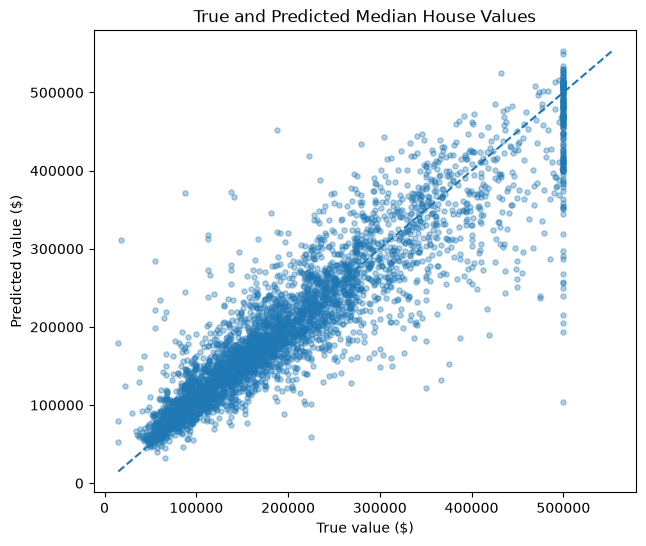

In [22]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    point_test_predictions,
    alpha=0.35,
    s=14
)

plot_minimum = min(
    y_test.min(),
    point_test_predictions.min()
)

plot_maximum = max(
    y_test.max(),
    point_test_predictions.max()
)

plt.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    linestyle="--"
)

plt.title(
    "True and Predicted Median House Values"
)

plt.xlabel("True value ($)")
plt.ylabel("Predicted value ($)")
plt.show()

## Point prediction 

Point-prediction results were:

| Model | MAE | RMSE | Median absolute error | R² |
|---|---:|---:|---:|---:|
| Constant median | $88,153.73 | $117,952.81 | $68,400.00 | -0.0543 |
| Squared-error boosting | $30,923.81 | $46,674.26 | $19,829.10 | 0.8349 |
| Median-quantile boosting | $31,529.92 | $49,511.80 | $18,965.51 | 0.8142 |

The squared-error model reduced MAE by:

`$57,229.92`, or approximately `64.92%`

It reduced RMSE by:

`$71,278.55`, or approximately `60.43%`

The squared-error model achieved better:

- MAE
- RMSE
- R²

The median-quantile model achieved a slightly lower median absolute error, meaning its typical prediction error was somewhat smaller even though its average and large errors were worse.

The scatter plot showed strong agreement around low- and middle-value block groups. However, predictions became more dispersed as true value increased.

The model showed regression toward the centre:

- very low values were frequently overestimated
- expensive values were frequently underestimated
- many observations capped at $500,001 received predictions far below the cap

The vertical group of observations at $500,001 also illustrates how target capping limits model evaluation at the upper end.

In [23]:
lower_test_predictions_raw = (
    lower_quantile_model.predict(
        X_test
    )
)

upper_test_predictions_raw = (
    upper_quantile_model.predict(
        X_test
    )
)

In [ ]:
quantile_crossing_mask = (
    lower_test_predictions_raw
    > upper_test_predictions_raw
)

number_of_crossings = int(
    quantile_crossing_mask.sum()
)

print(
    "Quantile crossings:",
    number_of_crossings
)

print(
    "Crossing percentage:",
    round(number_of_crossings/ len(X_test)* 100,3)
)

Quantile crossings: 6
Crossing percentage: 0.145


In [25]:
raw_lower_test = np.minimum(
    lower_test_predictions_raw,
    upper_test_predictions_raw
)

raw_upper_test = np.maximum(
    lower_test_predictions_raw,
    upper_test_predictions_raw
)

raw_lower_test = np.maximum(
    raw_lower_test,
    0
)

In [26]:
quantile_loss_df = pd.DataFrame({
    "quantile": [
        LOWER_QUANTILE,
        MEDIAN_QUANTILE,
        UPPER_QUANTILE
    ],
    "test_pinball_loss": [
        mean_pinball_loss(
            y_test,
            lower_test_predictions_raw,
            alpha=LOWER_QUANTILE
        ),
        mean_pinball_loss(
            y_test,
            median_test_predictions,
            alpha=MEDIAN_QUANTILE
        ),
        mean_pinball_loss(
            y_test,
            upper_test_predictions_raw,
            alpha=UPPER_QUANTILE
        )
    ]
})

quantile_loss_df

,quantile,test_pinball_loss
0,0.1,6650.460703
1,0.5,15764.961208
2,0.9,9234.927831


## Quantile regression 

The independently fitted lower and upper quantile models produced:

- Quantile crossings: 6
- Crossing percentage: 0.145%

Crossing was therefore rare but not completely absent.

Test pinball losses were:

| Quantile | Pinball loss |
|---:|---:|
| 0.10 | $6,650.46 |
| 0.50 | $15,764.96 |
| 0.90 | $9,234.93 |

The models were trained separately, so the predicted 10th percentile was not mathematically guaranteed to remain below the predicted 90th percentile.

The six crossed cases were corrected by treating the row-wise smaller prediction as the lower bound and the larger prediction as the upper bound.

The independently trained median model was also not guaranteed to lie inside the lower–upper interval. This caused the earlier plotting error when the median was used directly as the error-bar centre.

In [27]:
def calculate_interval_metrics(
    true_values,
    lower_bounds,
    upper_bounds,
    target_coverage=0.80
):
    true_values = np.asarray(
        true_values
    )

    lower_bounds = np.asarray(
        lower_bounds
    )

    upper_bounds = np.asarray(
        upper_bounds
    )

    covered = (
        (true_values >= lower_bounds)
        & (true_values <= upper_bounds)
    )

    widths = (
        upper_bounds - lower_bounds
    )

    return {
        "coverage":
            covered.mean(),

        "coverage_error":
            abs(
                covered.mean()
                - target_coverage
            ),

        "mean_width":
            widths.mean(),

        "median_width":
            np.median(widths),

        "minimum_width":
            widths.min(),

        "maximum_width":
            widths.max()
    }

In [28]:
raw_quantile_metrics = (
    calculate_interval_metrics(
        y_test,
        raw_lower_test,
        raw_upper_test,
        target_coverage=
            TARGET_COVERAGE
    )
)

pd.DataFrame({
    "metric":
        raw_quantile_metrics.keys(),
    "value":
        raw_quantile_metrics.values()
})

,metric,value
0,coverage,0.681444
1,coverage_error,0.118556
2,mean_width,85498.328161
3,median_width,72654.853492
4,minimum_width,286.451437
5,maximum_width,345492.723487


## Raw quantile interval 

The uncalibrated interval used the predicted 10th and 90th conditional percentiles.

It achieved:

- Coverage: 0.6814
- Target coverage: 0.8000
- Coverage error: 0.1186
- Mean width: $85,498.33
- Median width: $72,654.85
- Minimum width: $286.45
- Maximum width: $345,492.72

Only 68.14% of the test targets fell inside the nominal 80% interval.

The interval therefore under-covered by approximately 11.86 percentage points.

Its highly variable widths show that quantile regression learned adaptive uncertainty. However, some intervals were implausibly narrow, including a minimum width of only $286.45.

The raw quantile models underestimated the amount of uncertainty and required calibration before their intervals could be treated as approximately 80% intervals.

In [29]:
def finite_sample_conformal_quantile(
    scores,
    miscoverage_rate
):
    scores = np.asarray(scores)

    number_of_scores = len(scores)

    quantile_level = (
        np.ceil(
            (
                number_of_scores + 1
            )
            * (
                1 - miscoverage_rate
            )
        )
        / number_of_scores
    )

    quantile_level = min(
        quantile_level,
        1.0
    )

    try:
        return float(
            np.quantile(
                scores,
                quantile_level,
                method="higher"
            )
        )

    except TypeError:
        return float(
            np.quantile(
                scores,
                quantile_level,
                interpolation="higher"
            )
        )

In [30]:
point_calibration_predictions = (
    point_model.predict(
        X_calibration
    )
)

In [31]:
absolute_calibration_scores = (
    np.abs(
        y_calibration.to_numpy()
        - point_calibration_predictions
    )
)

fixed_conformal_correction = (
    finite_sample_conformal_quantile(
        absolute_calibration_scores,
        MISCOVERAGE_RATE
    )
)

print(
    "Fixed conformal correction:",
    f"${fixed_conformal_correction:,.0f}"
)

Fixed conformal correction: $46,124


In [32]:
fixed_lower_test = (
    point_test_predictions
    - fixed_conformal_correction
)

fixed_upper_test = (
    point_test_predictions
    + fixed_conformal_correction
)

fixed_lower_test = np.maximum(
    fixed_lower_test,
    0
)

In [33]:
fixed_conformal_metrics = (
    calculate_interval_metrics(
        y_test,
        fixed_lower_test,
        fixed_upper_test,
        target_coverage=
            TARGET_COVERAGE
    )
)

pd.DataFrame({
    "metric":
        fixed_conformal_metrics.keys(),
    "value":
        fixed_conformal_metrics.values()
})

,metric,value
0,coverage,0.796027
1,coverage_error,0.003973
2,mean_width,92243.353390
3,median_width,92248.742992
4,minimum_width,78610.355196
5,maximum_width,92248.742992


## Fixed width conformal interval 

The absolute-residual conformal correction was:

`approximately $46,124`

This correction was subtracted from and added to every point prediction.

The test interval achieved:

- Coverage: 0.7960
- Coverage error: 0.0040
- Mean width: $92,243.35
- Median width: $92,248.74
- Minimum width: $78,610.36
- Maximum width: $92,248.74

The unconstrained width was approximately:

`2 × $46,124 = $92,249`

The mean and minimum widths were slightly smaller because negative lower bounds were clipped to zero.

The interval covered 79.60% of test observations, only about 0.40 percentage points below the 80% target.

This was a major improvement over the raw quantile interval.

Its main limitation was that almost every observation received the same uncertainty width regardless of whether the case was easy or difficult.

In [34]:
lower_calibration_raw = (
    lower_quantile_model.predict(
        X_calibration
    )
)

upper_calibration_raw = (
    upper_quantile_model.predict(
        X_calibration
    )
)

lower_calibration = np.minimum(
    lower_calibration_raw,
    upper_calibration_raw
)

upper_calibration = np.maximum(
    lower_calibration_raw,
    upper_calibration_raw
)

In [35]:
cqr_calibration_scores = np.maximum(
    lower_calibration
    - y_calibration.to_numpy(),

    y_calibration.to_numpy()
    - upper_calibration
)

In [ ]:
cqr_correction = (
    finite_sample_conformal_quantile(
        cqr_calibration_scores,
        MISCOVERAGE_RATE
    )
)

print(
    "CQR correction:",
    f"${cqr_correction:,.0f}"
)

print(
    "Negative calibration-score rate:",
    round(
        np.mean(
            cqr_calibration_scores < 0
        ),4)
)

CQR correction: $6,630
Negative calibration-score rate: 0.6848


In [37]:
cqr_lower_test = (
    raw_lower_test
    - cqr_correction
)

cqr_upper_test = (
    raw_upper_test
    + cqr_correction
)

cqr_lower_test = np.maximum(
    cqr_lower_test,
    0
)

In [38]:
cqr_metrics = (
    calculate_interval_metrics(
        y_test,
        cqr_lower_test,
        cqr_upper_test,
        target_coverage=
            TARGET_COVERAGE
    )
)

pd.DataFrame({
    "metric":
        cqr_metrics.keys(),
    "value":
        cqr_metrics.values()
})

,metric,value
0,coverage,0.793120
1,coverage_error,0.006880
2,mean_width,98757.681313
3,median_width,85914.206645
4,minimum_width,13545.804589
5,maximum_width,358752.076640


## CQR calibration 

The CQR conformal correction was:

`approximately $6,630`

The correction was positive, so CQR expanded the raw lower and upper quantile intervals by approximately $6,630 on each side.

Before correction, 68.48% of calibration observations already fell within their raw quantile intervals.

The calibrated test interval achieved:

- Coverage: 0.7931
- Coverage error: 0.0069
- Mean width: $98,757.68
- Median width: $85,914.21
- Minimum width: $13,545.80
- Maximum width: $358,752.08

Coverage increased from 68.14% to 79.31%, an improvement of approximately 11.17 percentage points.

Mean interval width increased by approximately:

`$13,259.35`

The median CQR width was narrower than the fixed conformal width:

- CQR median: $85,914
- Fixed median: $92,249

However, CQR also produced some extremely wide intervals, raising its mean width above the fixed conformal result.

CQR therefore preserved adaptive uncertainty, but it did not provide better overall test coverage or mean-width efficiency than fixed conformal prediction on this split.

In [39]:
global_lower_value = float(
    y_train.quantile(
        LOWER_QUANTILE
    )
)

global_upper_value = float(
    y_train.quantile(
        UPPER_QUANTILE
    )
)

global_lower_test = np.full(
    len(y_test),
    global_lower_value
)

global_upper_test = np.full(
    len(y_test),
    global_upper_value
)

global_interval_metrics = (
    calculate_interval_metrics(
        y_test,
        global_lower_test,
        global_upper_test,
        target_coverage=
            TARGET_COVERAGE
    )
)

print(
    "Global interval:",
    f"${global_lower_value:,.0f}",
    "to",
    f"${global_upper_value:,.0f}"
)

Global interval: $82,300 to $376,600


In [40]:
interval_comparison_df = pd.DataFrame([
    {
        "method":
            "Global target interval",
        **global_interval_metrics
    },
    {
        "method":
            "Raw quantile interval",
        **raw_quantile_metrics
    },
    {
        "method":
            "Fixed split conformal",
        **fixed_conformal_metrics
    },
    {
        "method":
            "Conformalized quantile regression",
        **cqr_metrics
    }
]).sort_values(
    [
        "coverage_error",
        "mean_width"
    ],
    ascending=[
        True,
        True
    ]
)

interval_comparison_df

,method,coverage,coverage_error,mean_width,median_width,minimum_width,maximum_width
0,Global target interval,0.800145,0.000145,294300.000000,294300.000000,294300.000000,294300.000000
2,Fixed split conformal,0.796027,0.003973,92243.353390,92248.742992,78610.355196,92248.742992
3,Conformalized quantile regression,0.793120,0.006880,98757.681313,85914.206645,13545.804589,358752.076640
1,Raw quantile interval,0.681444,0.118556,85498.328161,72654.853492,286.451437,345492.723487


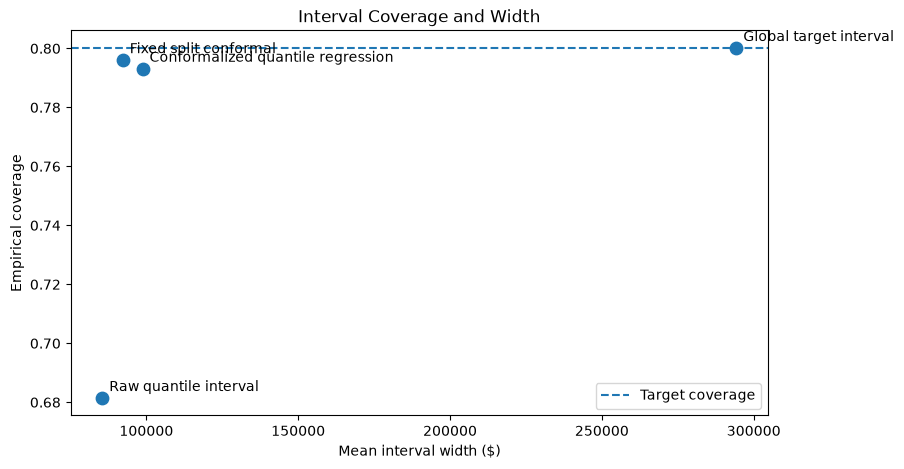

In [41]:
plt.figure(figsize=(9, 5))

plt.scatter(
    interval_comparison_df[
        "mean_width"
    ],
    interval_comparison_df[
        "coverage"
    ],
    s=80
)

for _, row in (
    interval_comparison_df.iterrows()
):
    plt.annotate(
        row["method"],
        (
            row["mean_width"],
            row["coverage"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(
    TARGET_COVERAGE,
    linestyle="--",
    label="Target coverage"
)

plt.title(
    "Interval Coverage and Width"
)

plt.xlabel("Mean interval width ($)")
plt.ylabel("Empirical coverage")
plt.legend()
plt.show()

## Interval comparison 

Interval performance was:

| Method | Coverage | Coverage error | Mean width | Median width |
|---|---:|---:|---:|---:|
| Global target interval | 0.8001 | 0.0001 | $294,300.00 | $294,300.00 |
| Fixed split conformal | 0.7960 | 0.0040 | $92,243.35 | $92,248.74 |
| CQR | 0.7931 | 0.0069 | $98,757.68 | $85,914.21 |
| Raw quantile interval | 0.6814 | 0.1186 | $85,498.33 | $72,654.85 |

The global target interval was:

`$82,300 to $376,600`

It was closest to exactly 80% coverage, but its width of $294,300 made it highly inefficient. It ignored all predictor information and supplied the same broad range to every observation.

The raw quantile interval was the narrowest method, but its coverage was far below the target.

Conformal calibration substantially improved raw quantile coverage.

Fixed split conformal performed slightly better than CQR on aggregate:

- Fixed coverage: 79.60%
- CQR coverage: 79.31%
- Fixed mean width: $92,243
- CQR mean width: $98,758

Under the notebook’s strict rule requiring observed test coverage of at least 80%, only the global target interval qualified.

However, among the useful model-based intervals, fixed split conformal offered the strongest coverage–width trade-off on this test split.

A conformal guarantee concerns marginal performance for exchangeable future observations. One finite test sample can still produce empirical coverage slightly below the nominal target.

In [42]:
visualisation_rng = np.random.default_rng(
    RANDOM_STATE
)

visualisation_indices = (
    visualisation_rng.choice(
        len(X_test),
        size=80,
        replace=False
    )
)

visualisation_order = np.argsort(
    median_test_predictions[
        visualisation_indices
    ]
)

visualisation_indices = (
    visualisation_indices[
        visualisation_order
    ]
)

In [43]:
visualisation_positions = np.arange(
    len(visualisation_indices)
)

selected_true = (
    y_test.to_numpy()[
        visualisation_indices
    ]
)

selected_median = (
    median_test_predictions[
        visualisation_indices
    ]
)

selected_lower = (
    cqr_lower_test[
        visualisation_indices
    ]
)

selected_upper = (
    cqr_upper_test[
        visualisation_indices
    ]
)

selected_errors = np.vstack([
    selected_median - selected_lower,
    selected_upper - selected_median
])

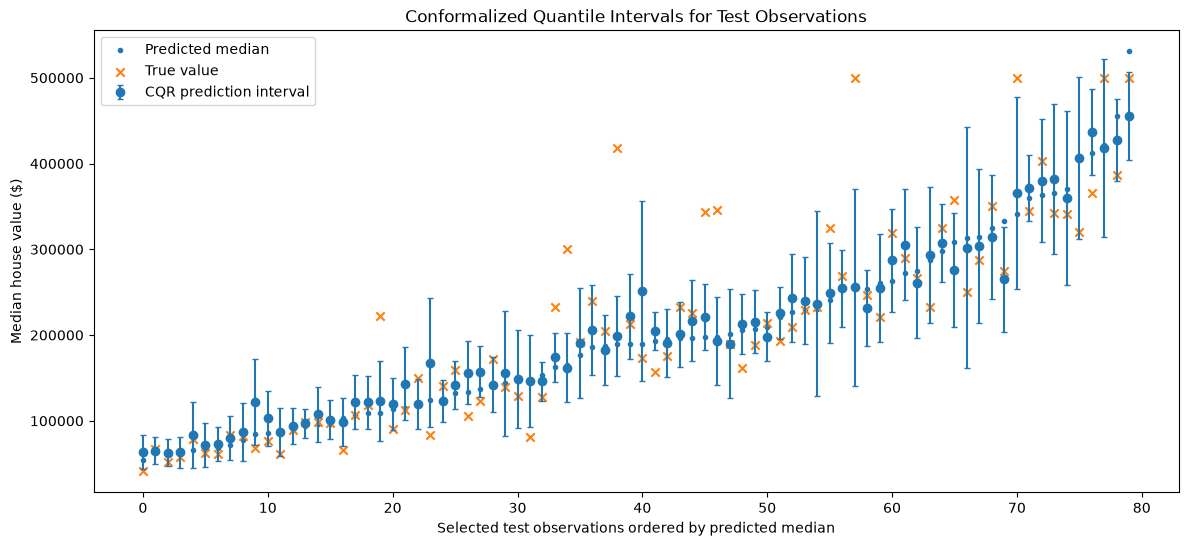

In [45]:
selected_interval_centre = (
    selected_lower + selected_upper
) / 2

selected_errors = np.vstack([
    selected_interval_centre - selected_lower,
    selected_upper - selected_interval_centre
])

plt.figure(figsize=(14, 6))

plt.errorbar(
    visualisation_positions,
    selected_interval_centre,
    yerr=selected_errors,
    fmt="o",
    capsize=2,
    label="CQR prediction interval"
)

plt.scatter(
    visualisation_positions,
    selected_median,
    marker=".",
    label="Predicted median"
)

plt.scatter(
    visualisation_positions,
    selected_true,
    marker="x",
    label="True value"
)

plt.title(
    "Conformalized Quantile Intervals for Test Observations"
)

plt.xlabel(
    "Selected test observations ordered by predicted median"
)

plt.ylabel("Median house value ($)")
plt.legend()
plt.show()

## Individual interval 

The CQR interval plot showed substantial variation in interval width.

Lower predicted values generally received narrower intervals, while many higher predicted values received wider intervals. However, width did not increase uniformly because it depended on the complete feature profile rather than predicted value alone.

Most selected true values fell inside their intervals, but several important misses were visible.

In particular:

- multiple true values at the $500,001 cap lay above their predicted intervals
- some high-value observations around $350,000–$420,000 were also above their intervals
- a few lower-valued observations received intervals located substantially too high

Some apparently strong median predictions still had broad intervals, indicating that a plausible point estimate did not necessarily imply low uncertainty.

The plot used each interval’s midpoint only as the graphical error-bar anchor. The independently predicted median was displayed separately because it was not always guaranteed to fall within the CQR lower and upper bounds.

In [46]:
cqr_analysis_df = X_test.reset_index(
    drop=True
).copy()

cqr_analysis_df[
    "true_value"
] = y_test.reset_index(
    drop=True
)

cqr_analysis_df[
    "point_prediction"
] = point_test_predictions

cqr_analysis_df[
    "median_prediction"
] = median_test_predictions

cqr_analysis_df[
    "lower_bound"
] = cqr_lower_test

cqr_analysis_df[
    "upper_bound"
] = cqr_upper_test

cqr_analysis_df[
    "interval_width"
] = (
    cqr_upper_test
    - cqr_lower_test
)

cqr_analysis_df[
    "absolute_error"
] = np.abs(
    cqr_analysis_df["true_value"]
    - cqr_analysis_df[
        "point_prediction"
    ]
)

cqr_analysis_df[
    "covered"
] = (
    (
        cqr_analysis_df["true_value"]
        >= cqr_analysis_df[
            "lower_bound"
        ]
    )
    &
    (
        cqr_analysis_df["true_value"]
        <= cqr_analysis_df[
            "upper_bound"
        ]
    )
)

In [47]:
cqr_analysis_df[
    "price_group"
] = pd.qcut(
    cqr_analysis_df["true_value"],
    q=5,
    duplicates="drop"
)

price_group_coverage_df = (
    cqr_analysis_df
    .groupby(
        "price_group",
        observed=True
    )
    .agg(
        observations=(
            "covered",
            "size"
        ),
        coverage=(
            "covered",
            "mean"
        ),
        mean_width=(
            "interval_width",
            "mean"
        ),
        mean_absolute_error=(
            "absolute_error",
            "mean"
        )
    )
    .reset_index()
)

price_group_coverage_df

,price_group,observations,coverage,mean_width,mean_absolute_error
0,"(14998.999, 107180.0]",826,0.780872,65479.172599,21025.010626
1,"(107180.0, 157300.0]",826,0.815981,78677.711963,23128.894732
2,"(157300.0, 209400.0]",826,0.855932,90682.902950,24378.555834
3,"(209400.0, 289960.0]",824,0.827670,114949.174748,32309.288607
4,"(289960.0, 500001.0]",826,0.685230,144038.648891,53780.630909


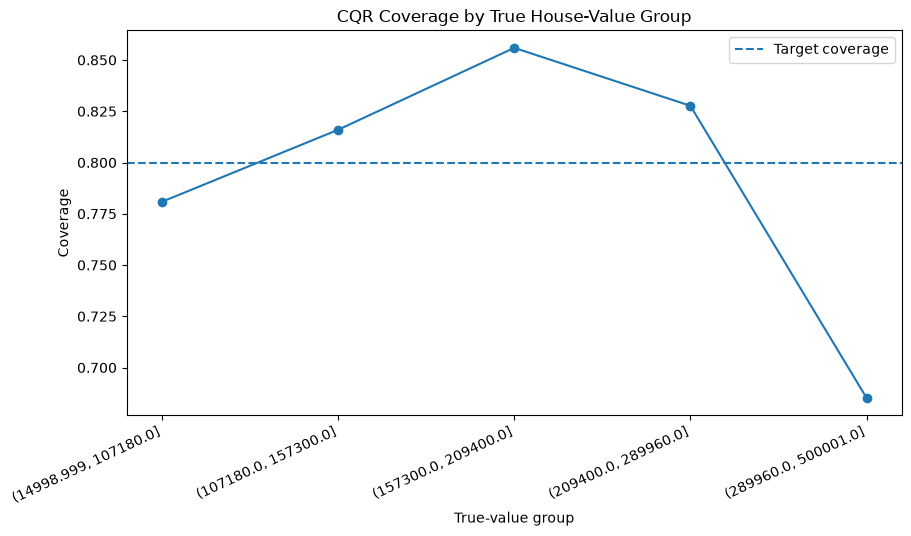

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(
        len(price_group_coverage_df)
    ),
    price_group_coverage_df[
        "coverage"
    ],
    marker="o"
)

plt.axhline(
    TARGET_COVERAGE,
    linestyle="--",
    label="Target coverage"
)

plt.xticks(
    range(
        len(price_group_coverage_df)
    ),
    price_group_coverage_df[
        "price_group"
    ].astype(str),
    rotation=25,
    ha="right"
)

plt.title(
    "CQR Coverage by True House-Value Group"
)

plt.xlabel("True-value group")
plt.ylabel("Coverage")
plt.legend()
plt.show()

## Price group coverage 

CQR performance by true-value quintile was:

| True-value group | Coverage | Mean width | Mean point error |
|---|---:|---:|---:|
| $14,999–$107,180 | 0.7809 | $65,479 | $21,025 |
| $107,180–$157,300 | 0.8160 | $78,678 | $23,129 |
| $157,300–$209,400 | 0.8559 | $90,683 | $24,379 |
| $209,400–$289,960 | 0.8277 | $114,949 | $32,309 |
| $289,960–$500,001 | 0.6852 | $144,039 | $53,781 |

The highest coverage occurred for:

`$157,300–$209,400`, with 85.59% coverage.

The lowest coverage occurred for:

`$289,960–$500,001`, with only 68.52% coverage.

Interval width increased consistently with true price level, rising from approximately $65,479 in the lowest group to $144,039 in the highest group.

Despite receiving the widest intervals, the most expensive group still had:

- the lowest coverage
- the highest point-prediction error

Many capped $500,001 observations were strongly underestimated. The target cap and scarcity of genuinely high-value examples likely contributed to this weakness.

The overall coverage near 80% therefore concealed substantial conditional under-coverage among expensive block groups.

In [49]:
cqr_analysis_df[
    "latitude_region"
] = pd.qcut(
    cqr_analysis_df["latitude"],
    q=4,
    labels=[
        "Southern",
        "South-central",
        "North-central",
        "Northern"
    ]
)

In [50]:
geographic_coverage_df = (
    cqr_analysis_df
    .groupby(
        "latitude_region",
        observed=True
    )
    .agg(
        observations=(
            "covered",
            "size"
        ),
        coverage=(
            "covered",
            "mean"
        ),
        mean_width=(
            "interval_width",
            "mean"
        ),
        mean_absolute_error=(
            "absolute_error",
            "mean"
        ),
        median_true_value=(
            "true_value",
            "median"
        )
    )
    .reset_index()
)

geographic_coverage_df

,latitude_region,observations,coverage,mean_width,mean_absolute_error,median_true_value
0,Southern,1068,0.806180,103322.086239,31382.098766,190900.0
1,South-central,1003,0.788634,101924.978667,32175.002586,188600.0
2,North-central,1034,0.814313,97846.204718,29166.544747,184150.0
3,Northern,1023,0.762463,91808.397925,30994.771793,147100.0


## Geographic coverage 

CQR performance by broad latitude region was:

| Region | Coverage | Mean width | Mean point error | Median true value |
|---|---:|---:|---:|---:|
| Southern | 0.8062 | $103,322 | $31,382 | $190,900 |
| South-central | 0.7886 | $101,925 | $32,175 | $188,600 |
| North-central | 0.8143 | $97,846 | $29,167 | $184,150 |
| Northern | 0.7625 | $91,808 | $30,995 | $147,100 |

North-central had the highest coverage:

`81.43%`

It also had the lowest mean point error.

Northern had the lowest coverage:

`76.25%`

Northern intervals were also the narrowest, averaging approximately $91,808. This suggests that the model assigned too little uncertainty to some observations in that region.

South-central had the largest mean point error and below-target coverage, while Southern achieved slightly above-target coverage with the widest intervals.

The relationship between point error and coverage was therefore meaningful but not perfect. Interval width also influenced whether regional errors were adequately covered.

In [51]:
width_error_correlation = (
    cqr_analysis_df[
        "interval_width"
    ]
    .corr(
        cqr_analysis_df[
            "absolute_error"
        ],
        method="spearman"
    )
)

print(
    "Spearman width-error correlation:",
    round(
        width_error_correlation,
        4
    )
)

Spearman width-error correlation: 0.4721


In [52]:
cqr_analysis_df[
    "width_group"
] = pd.qcut(
    cqr_analysis_df[
        "interval_width"
    ],
    q=5,
    duplicates="drop"
)

width_group_df = (
    cqr_analysis_df
    .groupby(
        "width_group",
        observed=True
    )
    .agg(
        observations=(
            "absolute_error",
            "size"
        ),
        mean_width=(
            "interval_width",
            "mean"
        ),
        mean_absolute_error=(
            "absolute_error",
            "mean"
        ),
        coverage=(
            "covered",
            "mean"
        )
    )
    .reset_index()
)

width_group_df

,width_group,observations,mean_width,mean_absolute_error,coverage
0,"(13545.804, 54867.844]",826,42003.836871,13633.479950,0.811138
1,"(54867.844, 75157.669]",825,65030.874315,20515.603370,0.812121
2,"(75157.669, 98664.224]",826,86280.084741,26937.555636,0.803874
3,"(98664.224, 139581.657]",825,116334.569771,35827.271508,0.791515
4,"(139581.657, 358752.077]",826,184119.488909,57698.451236,0.746973


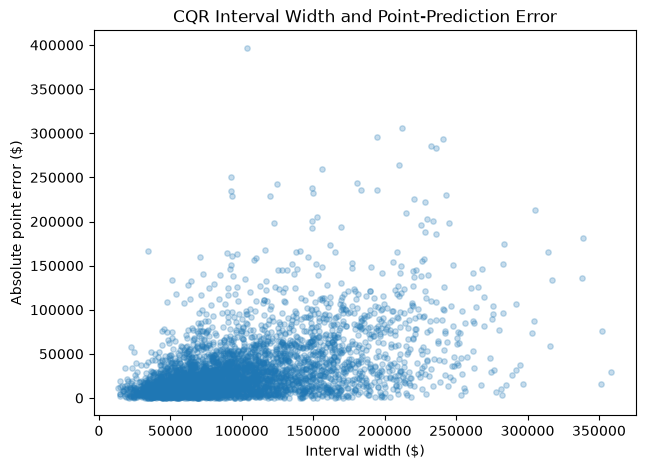

In [53]:
plt.figure(figsize=(7, 5))

plt.scatter(
    cqr_analysis_df[
        "interval_width"
    ],
    cqr_analysis_df[
        "absolute_error"
    ],
    alpha=0.25,
    s=15
)

plt.title(
    "CQR Interval Width and Point-Prediction Error"
)

plt.xlabel("Interval width ($)")
plt.ylabel("Absolute point error ($)")
plt.show()

## Uncertainty usefulness 

The Spearman correlation between CQR interval width and absolute point-prediction error was:

`0.4721`

This represents a moderate positive relationship.

The interval-width quintiles showed a clear monotonic pattern:

| Mean interval width | Mean absolute error | Coverage |
|---:|---:|---:|
| $42,004 | $13,633 | 0.8111 |
| $65,031 | $20,516 | 0.8121 |
| $86,280 | $26,938 | 0.8039 |
| $116,335 | $35,827 | 0.7915 |
| $184,119 | $57,698 | 0.7470 |

Wider intervals were assigned to genuinely more difficult observations.

Mean point error increased from approximately $13,633 in the narrowest-width group to $57,698 in the widest-width group.

This shows that CQR width contained useful case-level uncertainty information.

However, coverage declined in the widest group despite the larger ranges. The intervals correctly identified hard cases but did not widen enough to maintain 80% coverage among the most difficult observations.

In [54]:
training_feature_standard_deviations = (
    X_train.std().to_numpy()
)

noise_levels = [
    0.00,
    0.05,
    0.10,
    0.20
]

NOISE_REPETITIONS = 10

noise_rows = []

In [55]:
for noise_level in noise_levels:
    repetition_rows = []

    for repetition in range(
        NOISE_REPETITIONS
    ):
        noise_rng = np.random.default_rng(
            RANDOM_STATE
            + repetition
            + int(
                noise_level * 1_000
            )
        )

        noisy_test_array = (
            X_test.to_numpy()
            + noise_rng.normal(
                loc=0.0,
                scale=(
                    noise_level
                    * training_feature_standard_deviations
                ),
                size=X_test.shape
            )
        )

        noisy_test_df = pd.DataFrame(
            noisy_test_array,
            columns=feature_columns
        )

        noisy_point_predictions = (
            point_model.predict(
                noisy_test_df
            )
        )

        noisy_lower_raw = (
            lower_quantile_model.predict(
                noisy_test_df
            )
        )

        noisy_upper_raw = (
            upper_quantile_model.predict(
                noisy_test_df
            )
        )

        noisy_lower = np.minimum(
            noisy_lower_raw,
            noisy_upper_raw
        ) - cqr_correction

        noisy_upper = np.maximum(
            noisy_lower_raw,
            noisy_upper_raw
        ) + cqr_correction

        noisy_lower = np.maximum(
            noisy_lower,
            0
        )

        noisy_point_metrics = (
            calculate_point_metrics(
                y_test,
                noisy_point_predictions
            )
        )

        noisy_interval_metrics = (
            calculate_interval_metrics(
                y_test,
                noisy_lower,
                noisy_upper,
                target_coverage=
                    TARGET_COVERAGE
            )
        )

        repetition_rows.append({
            "mae":
                noisy_point_metrics[
                    "mae"
                ],
            "rmse":
                noisy_point_metrics[
                    "rmse"
                ],
            "coverage":
                noisy_interval_metrics[
                    "coverage"
                ],
            "mean_width":
                noisy_interval_metrics[
                    "mean_width"
                ]
        })

    noise_rows.append({
        "noise_level":
            noise_level,

        "mean_mae":
            np.mean([
                row["mae"]
                for row
                in repetition_rows
            ]),

        "mean_rmse":
            np.mean([
                row["rmse"]
                for row
                in repetition_rows
            ]),

        "mean_coverage":
            np.mean([
                row["coverage"]
                for row
                in repetition_rows
            ]),

        "mean_width":
            np.mean([
                row["mean_width"]
                for row
                in repetition_rows
            ])
    })

noise_robustness_df = pd.DataFrame(
    noise_rows
)

noise_robustness_df

,noise_level,mean_mae,mean_rmse,mean_coverage,mean_width
0,0.00,30923.805206,46674.256923,0.793120,98757.681313
1,0.05,42396.923733,61391.476476,0.706492,103567.707212
2,0.10,53267.096230,75092.883751,0.649128,112352.261394
3,0.20,67887.066593,92828.573206,0.603319,129035.870169


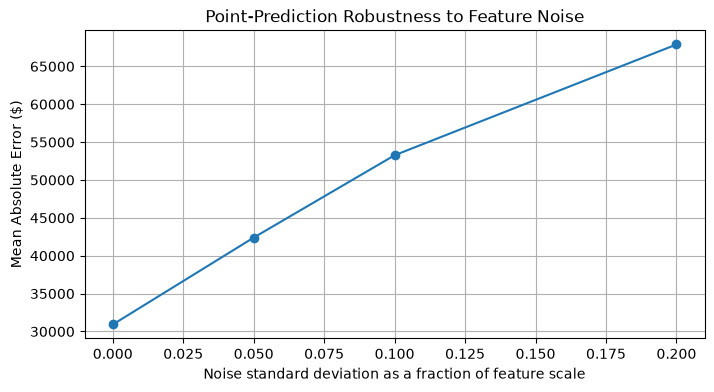

In [56]:
plt.figure(figsize=(8, 4))

plt.plot(
    noise_robustness_df[
        "noise_level"
    ],
    noise_robustness_df[
        "mean_mae"
    ],
    marker="o"
)

plt.title(
    "Point-Prediction Robustness to Feature Noise"
)

plt.xlabel(
    "Noise standard deviation "
    "as a fraction of feature scale"
)

plt.ylabel("Mean Absolute Error ($)")
plt.grid(True)
plt.show()

## Noise robustness 

Results under synthetic feature noise were:

| Noise level | Point MAE | RMSE | CQR coverage | Mean interval width |
|---:|---:|---:|---:|---:|
| 0.00 | $30,923.81 | $46,674.26 | 0.7931 | $98,757.68 |
| 0.05 | $42,396.92 | $61,391.48 | 0.7065 | $103,567.71 |
| 0.10 | $53,267.10 | $75,092.88 | 0.6491 | $112,352.26 |
| 0.20 | $67,887.07 | $92,828.57 | 0.6033 | $129,035.87 |

Performance deteriorated quickly.

At noise level 0.05:

- MAE increased by approximately $11,473
- coverage fell from 79.31% to 70.65%

At noise level 0.10:

- MAE was approximately 72% higher than under clean data
- coverage fell to 64.91%

The quantile models responded to noisy inputs by producing wider intervals. Mean width increased from approximately $98,758 to $129,036 at the highest noise level.

However, this widening was not sufficient to compensate for the rapidly increasing errors.

Substantial degradation was already visible at noise level 0.05.

The conformal correction had been calibrated on clean data. Adding feature noise changed the test distribution and weakened the exchangeability assumption underlying the original coverage guarantee.

In [57]:
uncovered_error_df = (
    cqr_analysis_df[
        ~cqr_analysis_df["covered"]
    ]
    .copy()
)

uncovered_error_df[
    "distance_to_interval"
] = np.maximum(
    uncovered_error_df[
        "lower_bound"
    ]
    - uncovered_error_df[
        "true_value"
    ],

    uncovered_error_df[
        "true_value"
    ]
    - uncovered_error_df[
        "upper_bound"
    ]
)

uncovered_error_df.sort_values(
    "distance_to_interval",
    ascending=False
)[
    [
        "true_value",
        "point_prediction",
        "lower_bound",
        "upper_bound",
        "distance_to_interval",
        "median_income",
        "median_house_age",
        "average_rooms",
        "average_occupancy",
        "latitude",
        "longitude"
    ]
].head(20)

,true_value,point_prediction,lower_bound,upper_bound,distance_to_interval,median_income,median_house_age,average_rooms,average_occupancy,latitude,longitude
404,500001.0,103387.860922,57992.209383,161881.637587,338119.362413,1.8750,33.0,141.909091,2.727273,38.91,-120.10
3464,475000.0,237110.299602,124647.425510,273487.283395,201512.716605,1.8214,21.0,2.966292,2.597753,34.06,-118.30
4039,500001.0,240080.555738,144040.944948,299944.788410,200056.211590,4.2039,11.0,6.753927,4.612565,37.19,-121.74
2737,500001.0,204561.207007,106297.463420,300992.471098,199008.528902,2.3846,22.0,5.152866,2.127389,33.48,-117.66
131,500001.0,249255.244059,209679.741624,301915.378049,198085.621951,3.1875,31.0,5.462185,2.436975,34.17,-118.57
2888,366700.0,131958.887399,77243.232470,169764.638114,196935.361886,3.0114,16.0,7.847458,2.016949,33.68,-116.25
2314,475000.0,239049.039083,98330.389498,281771.423132,193228.576868,2.4444,20.0,6.333333,2.066667,37.88,-122.22
2253,137500.0,373028.934534,312260.934354,506630.676574,174760.934354,10.2264,45.0,3.166667,1243.333333,38.32,-121.98
3114,418500.0,189998.780268,152838.717302,246039.036276,172460.963724,3.0926,6.0,3.673516,2.619863,34.24,-118.52
2068,500001.0,355120.847065,202818.448056,328139.250478,171861.749522,3.8456,27.0,5.627171,2.646578,34.43,-119.66


## Uncovered case 

The largest uncovered errors were predominantly high-value observations whose true targets lay above the predicted upper bound.

Among the 20 largest interval misses:

- 9 had the exact capped target of $500,001
- several others had values between approximately $418,500 and $478,600
- most were strongly underestimated

The largest miss had:

- True value: $500,001
- Point prediction: $103,388
- Interval: $57,992–$161,882
- Distance above the interval: $338,119
- Average rooms: 141.91

The average-room value was an extreme feature outlier.

There were also several large errors in the opposite direction.

One observation had:

- True value: $137,500
- Point prediction: $373,029
- Interval: $312,261–$506,631
- Average occupancy: 1,243.33

Another had:

- True value: $17,500
- Point prediction: $311,499
- Interval: $164,015–$404,562

These cases show that extreme feature values can lead to severe extrapolation or unusual tree assignments.

The largest failures were not caused only by narrow intervals. Several intervals were broad but were centred far from the true value because the underlying point and quantile predictions were severely biased.

An 80% interval is expected to miss approximately 20% of observations overall. The more important concern was that misses were concentrated among capped high-value targets and unusual feature combinations.